### Patient Stratification via Unsupervised Clustering

Discover patient subgroups in the TCGA-OV cohort using unsupervised learning on gene expression data. Validate the discovered subgroups using clinical outcomes (survival, demographic features).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

# Plot settings
sns.set_style("whitegrid")
np.random.seed(42)

# Load cleaned data from notebook 01
expr = pd.read_csv('../data/processed/expression_cleaned.csv', index_col=0)
clinical = pd.read_csv('../data/processed/clinical_aligned.csv')

print(f"Expression: {expr.shape} (genes x samples)")
print(f"Clinical: {clinical.shape}")
expr.iloc[:3, :5]

Expression: (19062, 300) (genes x samples)
Clinical: (300, 38)


,TCGA-04-1348-01,TCGA-04-1357-01,TCGA-04-1362-01,TCGA-04-1364-01,TCGA-04-1365-01
Hugo_Symbol,,,,,
EEF1A1,52277.622900,152674.031174,141899.920172,110270.100929,76743.884683
GAPDH,128030.337803,83403.811507,74977.195396,33720.358096,110735.083237
ACTB,142652.193771,112811.228287,91455.879172,111564.391289,123804.768217


### Feature selection: highly variable genes

We have 19,062 genes but most aren't informative for distinguishing patients. 
Many genes are:
- Constantly expressed across all patients (housekeeping genes: high but invariant)
- Constantly silent across all patients (no signal)
- Noisy with no biological variation

We focus on **highly variable genes**, genes whose expression *varies most* across 
patients. These are most likely to capture biological heterogeneity.

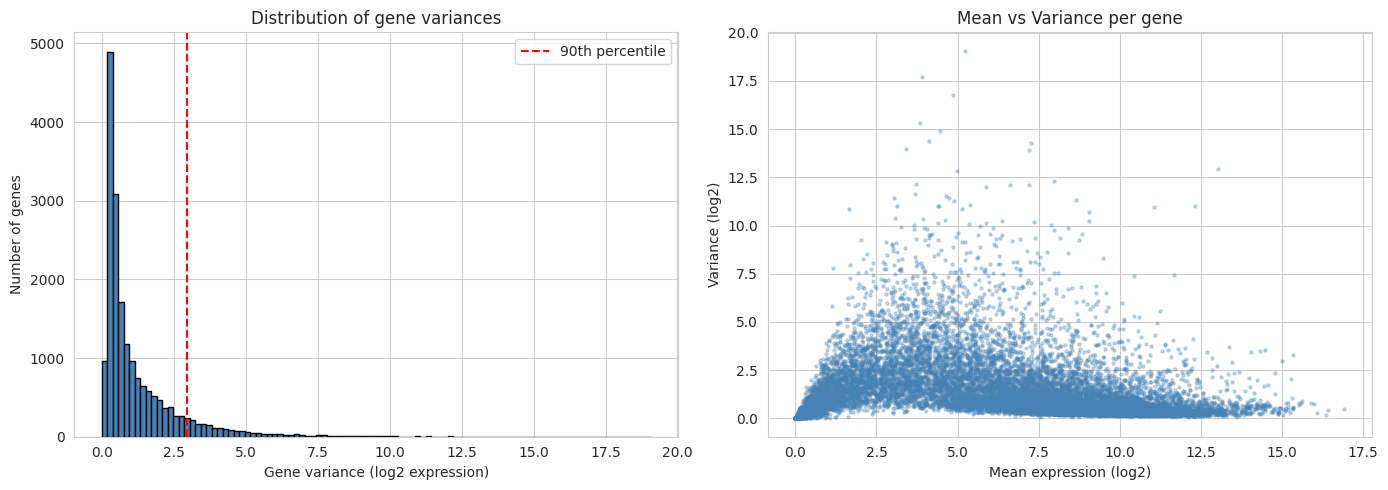

Genes total: 19,062
Median variance: 0.628
Variance at 90th percentile: 2.946


In [2]:
# Step 1: Log-transform
expr_log = np.log2(expr + 1)

# Step 2: Compute variance across samples for each gene
gene_variance = expr_log.var(axis=1)

# Step 3: Visualize variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(gene_variance, bins=100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Gene variance (log2 expression)')
axes[0].set_ylabel('Number of genes')
axes[0].set_title('Distribution of gene variances')
axes[0].axvline(gene_variance.quantile(0.9), color='red', linestyle='--', 
                label='90th percentile')
axes[0].legend()

# Mean vs variance plot
gene_mean = expr_log.mean(axis=1)
axes[1].scatter(gene_mean, gene_variance, alpha=0.3, s=5, c='steelblue')
axes[1].set_xlabel('Mean expression (log2)')
axes[1].set_ylabel('Variance (log2)')
axes[1].set_title('Mean vs Variance per gene')

plt.tight_layout()
plt.savefig('../figures/03_gene_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Genes total: {len(gene_variance):,}")
print(f"Median variance: {gene_variance.median():.3f}")
print(f"Variance at 90th percentile: {gene_variance.quantile(0.9):.3f}")

### Selecting top variable genes

Selecting the top 2,000 most variable genes. This is a common choice in the field

Trade-off:
- **Too few genes**: miss biological signal
- **Too many genes**: include noise and dilute the signal

In [3]:
N_HVG = 2000

# Get top N most variable genes
top_genes = gene_variance.sort_values(ascending=False).head(N_HVG).index.tolist()

# Subset the log-transformed expression matrix to these genes
expr_hvg = expr_log.loc[top_genes]

print(f"Selected {len(top_genes)} highly variable genes")
print(f"Expression matrix shape (HVGs x samples): {expr_hvg.shape}")

# Some of the top variable genes
print(f"\nTop 20 most variable genes:")
print(gene_variance.sort_values(ascending=False).head(20).round(2))

Selected 2000 highly variable genes
Expression matrix shape (HVGs x samples): (2000, 300)

Top 20 most variable genes:
Hugo_Symbol
GSTM1       19.07
DPEP3       17.72
PAX2        16.78
DLK1        15.31
ZIC1        14.91
MAGEA4      14.37
GSTT1       14.29
TKTL1       13.97
NLRP2       13.94
IGF2        12.96
LHX1        12.82
SFRP2       12.32
ADCY8       12.17
SST         12.12
SLC6A10P    12.11
LYPD2       12.01
ZIC2        11.62
EPYC        11.51
PRSS33      11.43
MAGEA11     11.40
dtype: float64


### Standardization

Before PCA and clustering, standardizing each gene (mean=0, std=1) across patients.

**Why?** Without standardization:
- Genes with naturally higher expression magnitudes would dominate distance calculations
- A gene with mean expression 12 would have more influence than one with mean 3
- We want each gene to contribute equally based on its *pattern across patients*, 
  not its absolute level

In [5]:
# Transpose: now rows = samples, columns = genes (standard ML format)
X = expr_hvg.T  # shape: (300 samples, 2000 genes)
print(f"Before scaling: shape={X.shape}, mean={X.values.mean():.2f}, std={X.values.std():.2f}")

# Standardize each gene (column) to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print(f"After scaling: shape={X_scaled.shape}, mean={X_scaled.values.mean():.4f}, std={X_scaled.values.std():.4f}")

Before scaling: shape=(300, 2000), mean=4.80, std=3.16
After scaling: shape=(300, 2000), mean=0.0000, std=1.0000


### Principal Component Analysis (PCA)

We have 2,000 dimensions (genes), too many for visualization or clustering. PCA finds 
the directions of greatest variation and projects the data onto those axes.

**Why PCA before UMAP/clustering?**
- Removes noise
- Speeds up downstream methods
- Standard practice in single-cell and bulk RNA-seq pipelines

PCA output shape: (300, 50)
Variance explained by first 5 PCs: [0.1   0.072 0.042 0.031 0.029]
Cumulative variance (first 30 PCs): 0.560


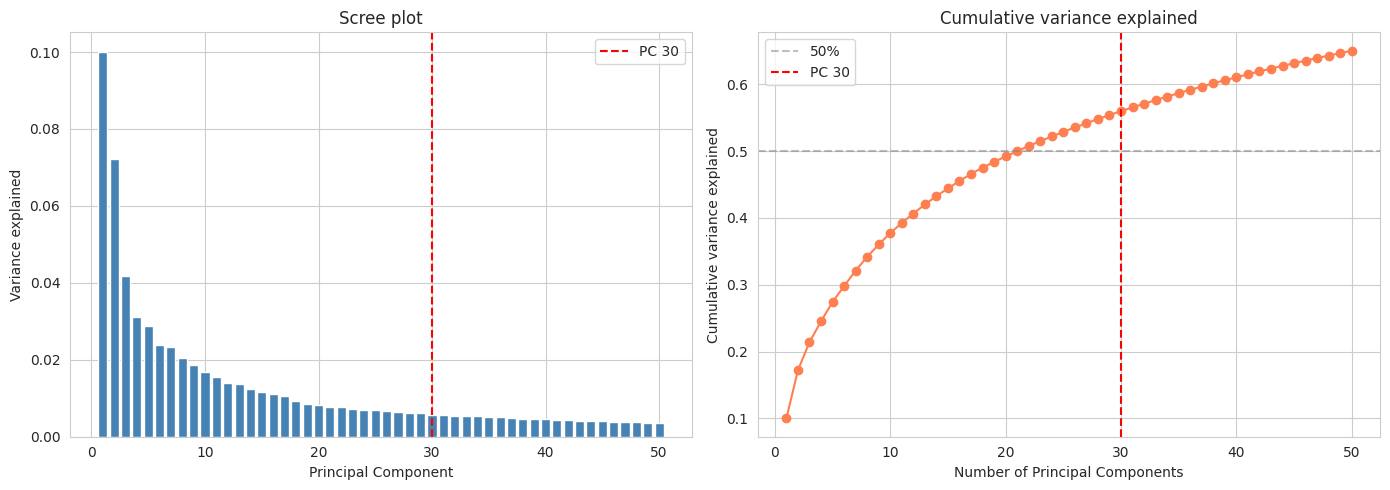

In [6]:
# Run PCA - compute many components first to choose how many to keep
n_components = 50
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA output shape: {X_pca.shape}")
print(f"Variance explained by first 5 PCs: {pca.explained_variance_ratio_[:5].round(3)}")
print(f"Cumulative variance (first 30 PCs): {pca.explained_variance_ratio_[:30].sum():.3f}")

# Plot scree plot and cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained')
axes[0].set_title('Scree plot')
axes[0].axvline(x=30, color='red', linestyle='--', label='PC 30')
axes[0].legend()

# Cumulative variance
cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, n_components + 1), cumulative, marker='o', color='coral')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title('Cumulative variance explained')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1].axvline(x=30, color='red', linestyle='--', label='PC 30')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/04_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualizing PCA

Let's also plot the data along the first two PCs to see if any structure is already visible.

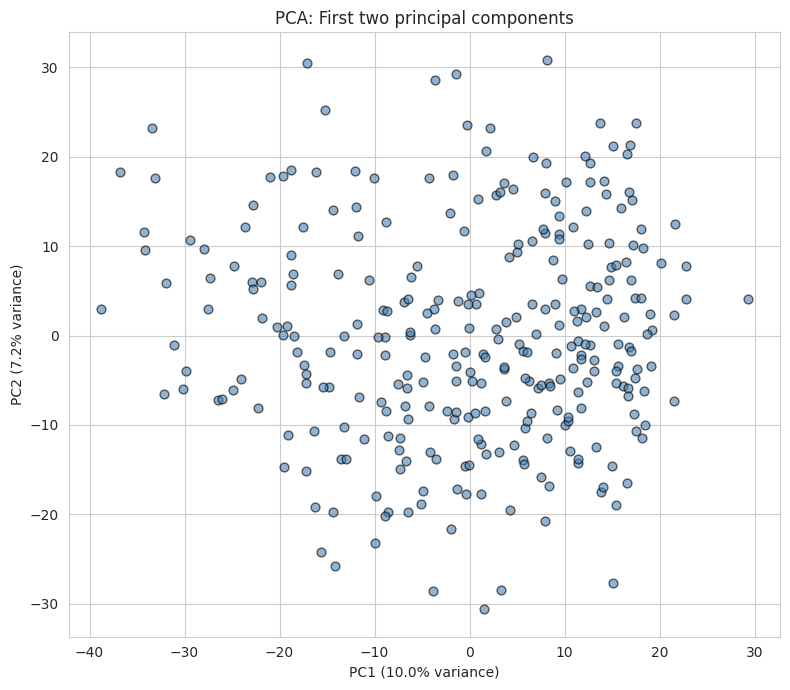

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=40, c='steelblue', edgecolor='black')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: First two principal components')
plt.tight_layout()
plt.savefig('../figures/05_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### UMAP for nonlinear visualization

PCA is **linear**, it projects data along straight axes.
UMAP is **nonlinear**, it preserves the local neighborhood structure of points, which often reveals subtle groups that PCA misses.

We run UMAP on the top 30 PCs (not on the original 2000 features) for two reasons:
1. **Speed**: 30 dimensions instead of 2000
2. **Denoising**: Higher PCs are mostly noise; UMAP focuses on biological signal

Running UMAP on 30 PCs...


/home/raihan/Materials/Research/Cancer Data Science/code/ovarian-cancer-regulatory-analysis/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (300, 2)


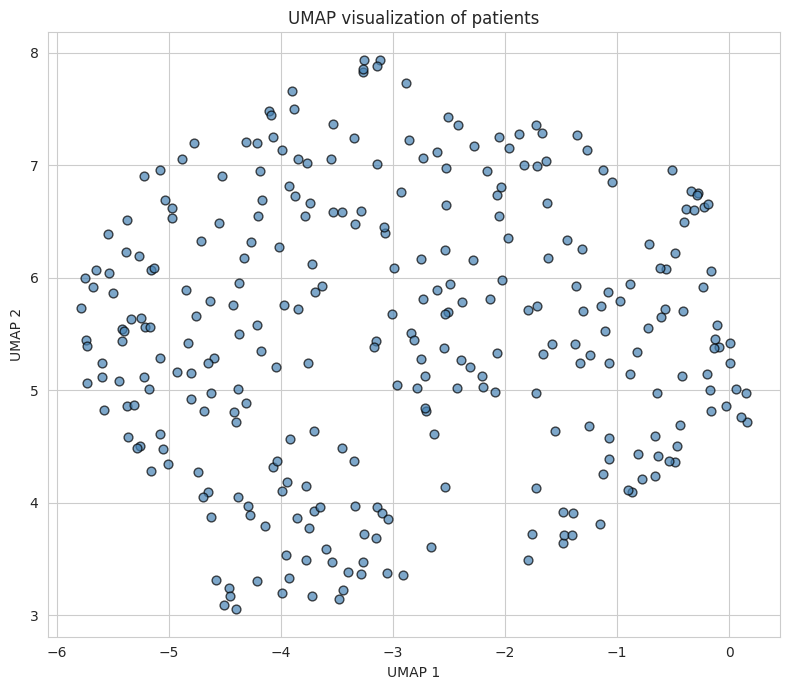

In [8]:
# Use the top 30 PCs as input to UMAP
N_PCS = 30
X_pca_30 = X_pca[:, :N_PCS]

print(f"Running UMAP on {N_PCS} PCs...")
reducer = umap.UMAP(
    n_neighbors=15,    # Balance local vs global structure
    min_dist=0.1,      # How tightly points cluster
    n_components=2,    # 2D output
    random_state=42
)
X_umap = reducer.fit_transform(X_pca_30)

print(f"UMAP output shape: {X_umap.shape}")

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.7, s=40, c='steelblue', edgecolor='black')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP visualization of patients')
plt.tight_layout()
plt.savefig('../figures/06_umap.png', dpi=150, bbox_inches='tight')
plt.show()

### Choosing the number of clusters with K-means

K-means requires to specify the number of clusters K. We use two methods to choose K:

1. **Elbow method**: plot the within-cluster sum of squares (inertia) for different K. Look for the "elbow" where adding more clusters stops helping much.
2. **Silhouette score**: measures how well-separated the clusters are. Higher = better.

Testing K from 2 to 8.

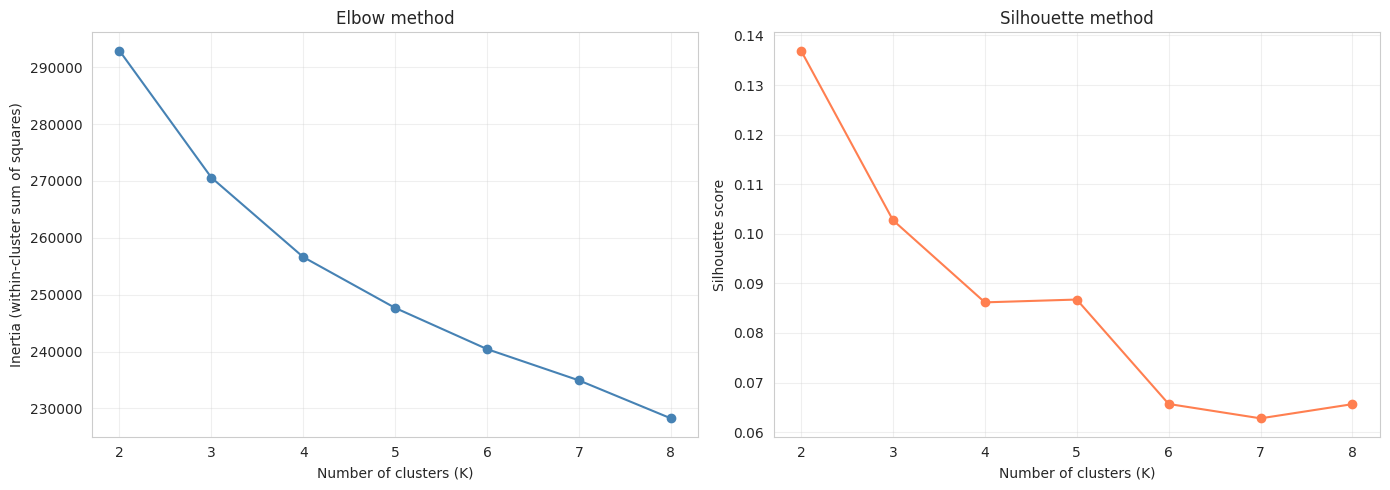

K=2: inertia=292,892, silhouette=0.1369
K=3: inertia=270,592, silhouette=0.1027
K=4: inertia=256,616, silhouette=0.0862
K=5: inertia=247,679, silhouette=0.0867
K=6: inertia=240,440, silhouette=0.0657
K=7: inertia=234,940, silhouette=0.0628
K=8: inertia=228,266, silhouette=0.0656


In [9]:
# Test multiple values of K
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_30)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_30, labels))

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='o', color='coral')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette method')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_choosing_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Print scores
for k, inertia, sil in zip(K_range, inertias, silhouettes):
    print(f"K={k}: inertia={inertia:,.0f}, silhouette={sil:.4f}")

### Interpreting cluster metrics

The silhouette scores are all relatively low (max 0.137 at K=2), and the elbow plot shows smooth decay without a clear inflection point. This indicates that the patients do not form sharp, well-separated clusters in expression space.

**This is consistent with the HGSC literature**, which describes ovarian cancer as exhibiting a *continuum* of molecular states rather than discrete subtypes. Several landmark studies (Tothill 2008, TCGA 2011) report 4 subtypes (immunoreactive, differentiated, proliferative, mesenchymal), but the boundaries between them are known to be fuzzy.

**Strategy:** We will examine two clustering granularities:
- **K=2**: highest silhouette score, captures the strongest split
- **K=4**: matches the TCGA 2011 literature standard, allows comparison with known subtypes

We will then test whether either clustering corresponds to clinically meaningful groups (differential survival).

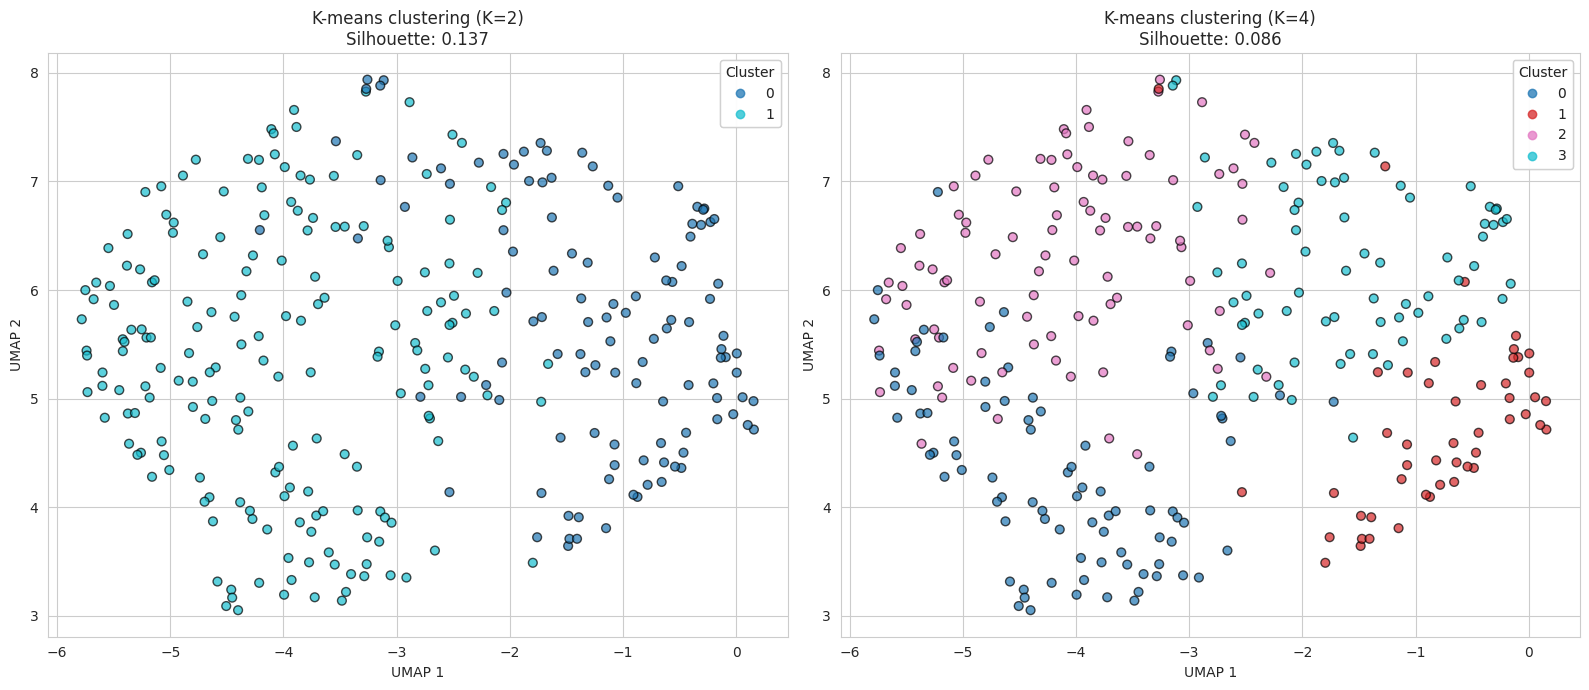

K=2 cluster sizes:
0    113
1    187
Name: count, dtype: int64

K=4 cluster sizes:
0    86
1    48
2    93
3    73
Name: count, dtype: int64


In [10]:
# Run K-means with both K values
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_pca_30)

kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_pca_30)

# Visualize both clusterings on the UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K=2
scatter1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=labels_k2, cmap='tab10',
                            alpha=0.7, s=40, edgecolor='black')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].set_title(f'K-means clustering (K=2)\nSilhouette: {silhouettes[0]:.3f}')
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Cluster", loc='best')
axes[0].add_artist(legend1)

# K=4
scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=labels_k4, cmap='tab10',
                            alpha=0.7, s=40, edgecolor='black')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].set_title(f'K-means clustering (K=4)\nSilhouette: {silhouettes[2]:.3f}')
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster", loc='best')
axes[1].add_artist(legend2)

plt.tight_layout()
plt.savefig('../figures/08_clusters_on_umap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print cluster sizes
print("K=2 cluster sizes:")
print(pd.Series(labels_k2).value_counts().sort_index())
print("\nK=4 cluster sizes:")
print(pd.Series(labels_k4).value_counts().sort_index())

In [11]:
# Build a dataframe of patient IDs with cluster assignments
sample_ids = X_scaled.index.tolist()
patient_ids = ['-'.join(s.split('-')[:3]) for s in sample_ids]

cluster_df = pd.DataFrame({
    'sample_id': sample_ids,
    'patient_id': patient_ids,
    'cluster_k2': labels_k2,
    'cluster_k4': labels_k4,
    'umap_1': X_umap[:, 0],
    'umap_2': X_umap[:, 1],
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1]
})

cluster_df.to_csv('../data/processed/cluster_assignments.csv', index=False)
print(f"Saved cluster assignments for {len(cluster_df)} samples")
cluster_df.head()

Saved cluster assignments for 300 samples


,sample_id,patient_id,cluster_k2,cluster_k4,umap_1,umap_2,pc1,pc2
0,TCGA-04-1348-01,TCGA-04-1348,1,2,-3.988613,7.131998,7.487360,-15.792559
1,TCGA-04-1357-01,TCGA-04-1357,1,2,-3.766484,7.016850,13.264013,-12.445676
2,TCGA-04-1362-01,TCGA-04-1362,0,3,-1.369218,5.922454,-6.779072,-7.873691
3,TCGA-04-1364-01,TCGA-04-1364,0,1,-0.130396,5.455799,-29.895526,-3.949073
4,TCGA-04-1365-01,TCGA-04-1365,1,2,-3.539994,6.580864,1.206324,-12.081928


### Validating clusters with survival analysis

Even though our clusters are not sharply separated in expression space, they may still capture biologically meaningful differences. An insightful test for clinical relevance is **whether different clusters have different survival outcomes**.

We perform two types of analysis:

1. **Kaplan-Meier curves**: visualize survival probability over time per cluster
2. **Log-rank test**: statistical test for whether survival curves differ significantly


In [12]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

# Merge cluster assignments with clinical data
merged = cluster_df.merge(clinical, left_on='patient_id', right_on='PATIENT_ID', how='inner')

# Convert OS_STATUS to binary (1=deceased, 0=living)
merged['OS_EVENT'] = merged['OS_STATUS'].map({'1:DECEASED': 1, '0:LIVING': 0})

# Drop patients with missing survival data
n_before = len(merged)
merged = merged.dropna(subset=['OS_MONTHS', 'OS_EVENT'])
n_after = len(merged)
print(f"Patients before filtering: {n_before}")
print(f"Patients after filtering missing survival: {n_after}")
print(f"Dropped: {n_before - n_after}")

# Verify cluster sizes after filtering
print("\nCluster sizes after filtering:")
print("K=2:", merged['cluster_k2'].value_counts().sort_index().tolist())
print("K=4:", merged['cluster_k4'].value_counts().sort_index().tolist())

Patients before filtering: 300
Patients after filtering missing survival: 299
Dropped: 1

Cluster sizes after filtering:
K=2: [113, 186]
K=4: [86, 48, 92, 73]


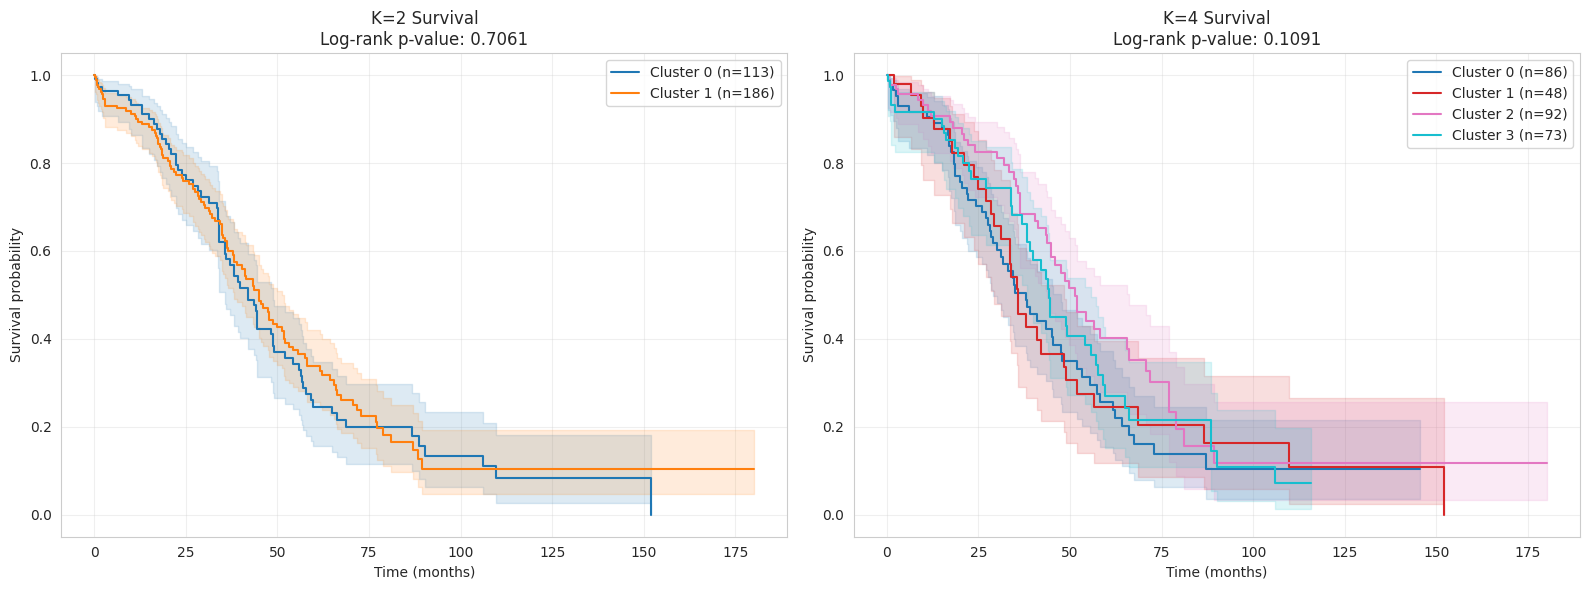


--- Statistical Tests ---
K=2 Log-rank p-value: 0.7061
K=4 Log-rank p-value: 0.1091


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K=2 Kaplan-Meier
kmf = KaplanMeierFitter()
ax = axes[0]
colors_k2 = ['#1f77b4', '#ff7f0e']

for cluster_id in sorted(merged['cluster_k2'].unique()):
    mask = merged['cluster_k2'] == cluster_id
    kmf.fit(
        durations=merged.loc[mask, 'OS_MONTHS'],
        event_observed=merged.loc[mask, 'OS_EVENT'],
        label=f'Cluster {cluster_id} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, color=colors_k2[cluster_id], ci_alpha=0.15)

# Log-rank test for K=2
lr_k2 = logrank_test(
    durations_A=merged[merged['cluster_k2']==0]['OS_MONTHS'],
    durations_B=merged[merged['cluster_k2']==1]['OS_MONTHS'],
    event_observed_A=merged[merged['cluster_k2']==0]['OS_EVENT'],
    event_observed_B=merged[merged['cluster_k2']==1]['OS_EVENT']
)

ax.set_title(f'K=2 Survival\nLog-rank p-value: {lr_k2.p_value:.4f}')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.grid(True, alpha=0.3)

# K=4 Kaplan-Meier
ax = axes[1]
colors_k4 = ['#1f77b4', '#d62728', '#e377c2', '#17becf']

for cluster_id in sorted(merged['cluster_k4'].unique()):
    mask = merged['cluster_k4'] == cluster_id
    kmf.fit(
        durations=merged.loc[mask, 'OS_MONTHS'],
        event_observed=merged.loc[mask, 'OS_EVENT'],
        label=f'Cluster {cluster_id} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, color=colors_k4[cluster_id], ci_alpha=0.15)

# Multivariate log-rank for K=4
lr_k4 = multivariate_logrank_test(
    event_durations=merged['OS_MONTHS'],
    groups=merged['cluster_k4'],
    event_observed=merged['OS_EVENT']
)

ax.set_title(f'K=4 Survival\nLog-rank p-value: {lr_k4.p_value:.4f}')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/09_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Statistical Tests ---")
print(f"K=2 Log-rank p-value: {lr_k2.p_value:.4f}")
print(f"K=4 Log-rank p-value: {lr_k4.p_value:.4f}")

### Pairwise comparison of K=4 clusters

The overall log-rank test gave p=0.11, but visual inspection suggests Cluster 2 has better survival than the others. Let's test this hypothesis more rigorously by comparing Cluster 2 vs all others.

Median survival by cluster:
  Cluster 0: n=86, deaths=57, median OS=38.0 months
  Cluster 1: n=48, deaths=31, median OS=35.8 months
  Cluster 2: n=92, deaths=48, median OS=51.4 months
  Cluster 3: n=73, deaths=44, median OS=44.3 months

Cluster 2 vs others: log-rank p-value = 0.0281
Cluster 2 has BETTER prognosis


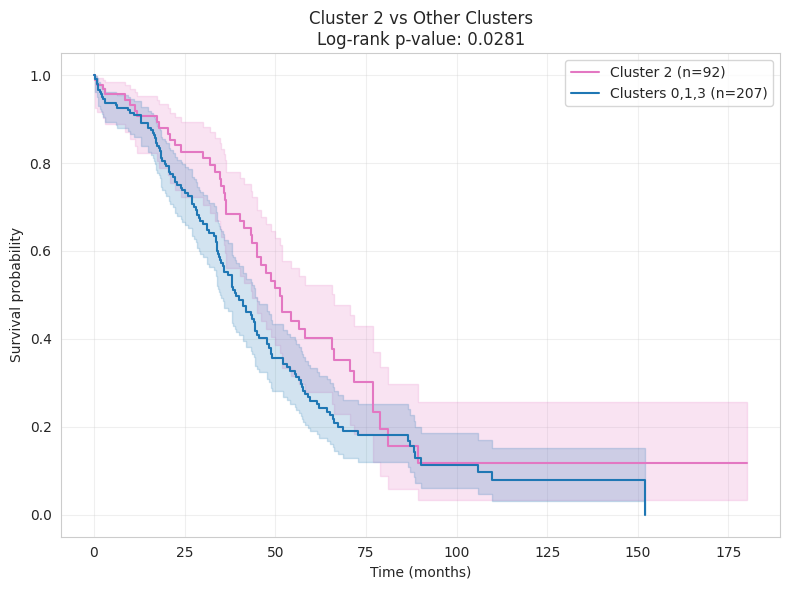

In [14]:
# Test Cluster 2 vs all others combined
mask_c2 = merged['cluster_k4'] == 2
mask_others = merged['cluster_k4'] != 2

lr_c2_vs_others = logrank_test(
    durations_A=merged.loc[mask_c2, 'OS_MONTHS'],
    durations_B=merged.loc[mask_others, 'OS_MONTHS'],
    event_observed_A=merged.loc[mask_c2, 'OS_EVENT'],
    event_observed_B=merged.loc[mask_others, 'OS_EVENT']
)

# Median survival per cluster
print("Median survival by cluster:")
for c in sorted(merged['cluster_k4'].unique()):
    mask = merged['cluster_k4'] == c
    kmf = KaplanMeierFitter().fit(
        merged.loc[mask, 'OS_MONTHS'], 
        merged.loc[mask, 'OS_EVENT']
    )
    median = kmf.median_survival_time_
    n = mask.sum()
    n_events = merged.loc[mask, 'OS_EVENT'].sum()
    print(f"  Cluster {c}: n={n}, deaths={n_events}, median OS={median:.1f} months")

print(f"\nCluster 2 vs others: log-rank p-value = {lr_c2_vs_others.p_value:.4f}")
print(f"Cluster 2 has {'BETTER' if merged[mask_c2]['OS_EVENT'].mean() < merged[mask_others]['OS_EVENT'].mean() else 'WORSE'} prognosis")

# Plot Cluster 2 vs others
fig, ax = plt.subplots(figsize=(8, 6))
kmf = KaplanMeierFitter()

kmf.fit(merged.loc[mask_c2, 'OS_MONTHS'], merged.loc[mask_c2, 'OS_EVENT'],
        label=f'Cluster 2 (n={mask_c2.sum()})')
kmf.plot_survival_function(ax=ax, color='#e377c2', ci_alpha=0.2)

kmf.fit(merged.loc[mask_others, 'OS_MONTHS'], merged.loc[mask_others, 'OS_EVENT'],
        label=f'Clusters 0,1,3 (n={mask_others.sum()})')
kmf.plot_survival_function(ax=ax, color='#1f77b4', ci_alpha=0.2)

ax.set_title(f'Cluster 2 vs Other Clusters\nLog-rank p-value: {lr_c2_vs_others.p_value:.4f}')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/10_cluster2_vs_others.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Find genes that are differentially expressed between Cluster 2 and others
from scipy.stats import ttest_ind

# Map sample IDs to cluster_k4 labels
sample_to_cluster = dict(zip(cluster_df['sample_id'], cluster_df['cluster_k4']))
sample_clusters = pd.Series([sample_to_cluster[s] for s in expr_log.columns], index=expr_log.columns)

# Compare cluster 2 vs others
samples_c2 = sample_clusters[sample_clusters == 2].index
samples_others = sample_clusters[sample_clusters != 2].index

print(f"Cluster 2 samples: {len(samples_c2)}")
print(f"Other samples: {len(samples_others)}")

# Run t-test for every gene
results = []
for gene in expr_log.index:
    vals_c2 = expr_log.loc[gene, samples_c2].values
    vals_other = expr_log.loc[gene, samples_others].values
    
    mean_c2 = vals_c2.mean()
    mean_other = vals_other.mean()
    log2fc = mean_c2 - mean_other  # Already log-transformed, so subtraction = log2 fold change
    
    try:
        _, pval = ttest_ind(vals_c2, vals_other, equal_var=False)
    except:
        pval = 1.0
    
    results.append({
        'gene': gene,
        'mean_c2': mean_c2,
        'mean_other': mean_other,
        'log2fc': log2fc,
        'pvalue': pval
    })

de_results = pd.DataFrame(results)

# Top upregulated in cluster 2
print("\nTop 15 genes UP in Cluster 2:")
print(de_results.sort_values('log2fc', ascending=False).head(15)[['gene', 'log2fc', 'pvalue']].to_string(index=False))

print("\nTop 15 genes DOWN in Cluster 2:")
print(de_results.sort_values('log2fc', ascending=True).head(15)[['gene', 'log2fc', 'pvalue']].to_string(index=False))

# Save results
de_results.to_csv('../data/processed/de_cluster2_vs_others.csv', index=False)

Cluster 2 samples: 93
Other samples: 207


/home/raihan/Materials/Research/Cancer Data Science/code/ovarian-cancer-regulatory-analysis/.venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 15 genes UP in Cluster 2:
    gene   log2fc       pvalue
    GNLY 2.025120 9.638332e-16
ADAMDEC1 2.013184 2.274684e-12
     IGJ 2.005724 3.447045e-08
    IDO1 1.906068 2.650051e-14
  CXCL13 1.881502 1.322409e-09
   ADAM6 1.872923 1.615824e-06
  CXCL11 1.871322 1.196188e-14
  CXCL10 1.840533 1.239455e-15
     UBD 1.752442 3.589692e-09
 CXCR2P1 1.740606 1.321189e-10
  ZNF683 1.730280 2.649790e-14
   CXCL9 1.721013 1.377480e-08
    PIGR 1.687719 9.332888e-05
    GZMB 1.687248 9.006595e-14
 PLA2G2D 1.665491 2.368504e-08

Top 15 genes DOWN in Cluster 2:
  gene    log2fc       pvalue
COL2A1 -3.079617 1.214306e-19
 PTPRT -3.033842 6.401692e-23
  DLK1 -2.917459 3.513103e-12
TUBB2B -2.735089 1.263865e-17
  FBN3 -2.657227 1.666955e-11
  LHX1 -2.611681 1.981742e-09
 CNTFR -2.575591 4.693701e-11
  IGF2 -2.549841 3.297231e-08
 KIF1A -2.471983 8.230587e-10
NKAIN4 -2.465656 6.543410e-18
  BEX1 -2.393219 5.769187e-12
ATP1A2 -2.379814 4.911548e-21
KCNIP1 -2.353465 3.864283e-18
    C7 -2.349407 3.2

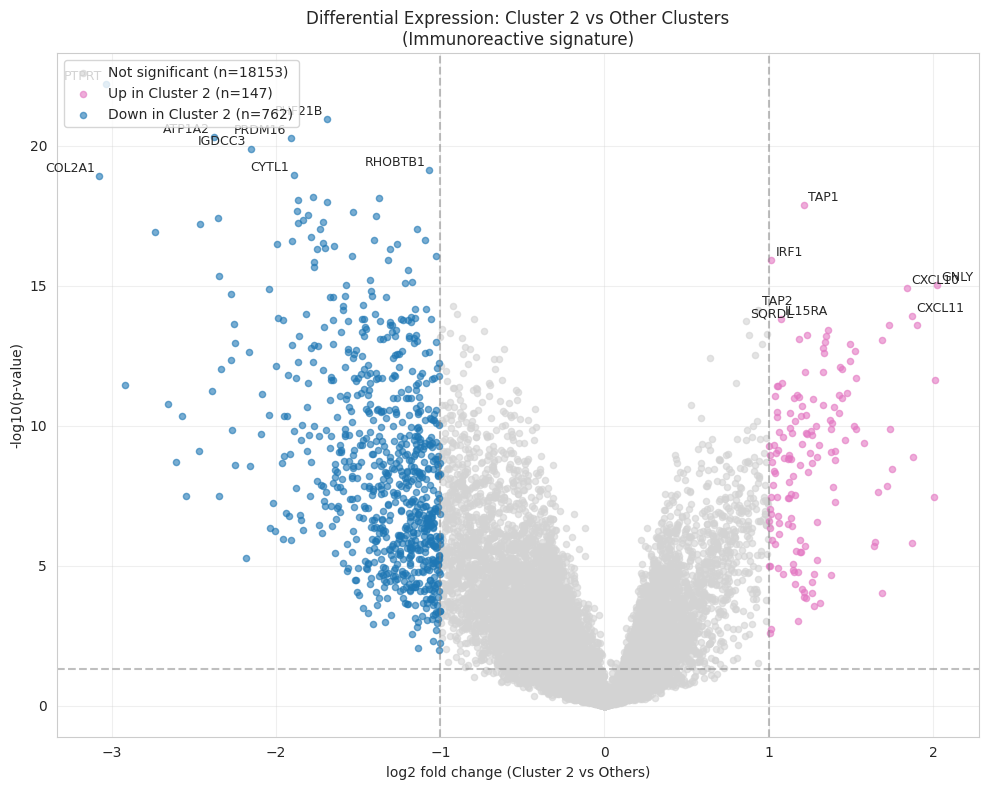


Significant genes (|log2FC| > 1, p < 0.05):
  Upregulated in Cluster 2: 147
  Downregulated in Cluster 2: 762


In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate -log10(pvalue) for visualization
de_results['neg_log10_p'] = -np.log10(de_results['pvalue'].clip(lower=1e-300))

# Define significance thresholds
LOG2FC_THRESHOLD = 1.0  # 2-fold change
PVAL_THRESHOLD = 0.05

# Categorize each gene
def categorize(row):
    if row['pvalue'] >= PVAL_THRESHOLD:
        return 'Not significant'
    elif row['log2fc'] >= LOG2FC_THRESHOLD:
        return 'Up in Cluster 2'
    elif row['log2fc'] <= -LOG2FC_THRESHOLD:
        return 'Down in Cluster 2'
    else:
        return 'Not significant'

de_results['category'] = de_results.apply(categorize, axis=1)

# Plot each category
colors = {
    'Not significant': 'lightgray',
    'Up in Cluster 2': '#e377c2',
    'Down in Cluster 2': '#1f77b4'
}

for cat, color in colors.items():
    mask = de_results['category'] == cat
    ax.scatter(de_results.loc[mask, 'log2fc'], de_results.loc[mask, 'neg_log10_p'],
               c=color, alpha=0.6, s=20, label=f"{cat} (n={mask.sum()})")

# Annotate top 10 most significant up and down genes
for direction, sign in [('up', 1), ('down', -1)]:
    if direction == 'up':
        top = de_results[de_results['log2fc'] > 0].sort_values('pvalue').head(8)
    else:
        top = de_results[de_results['log2fc'] < 0].sort_values('pvalue').head(8)
    
    for _, row in top.iterrows():
        ax.annotate(row['gene'], (row['log2fc'], row['neg_log10_p']),
                    fontsize=9, ha='left' if sign > 0 else 'right',
                    xytext=(3*sign, 3), textcoords='offset points')

# Threshold lines
ax.axhline(-np.log10(PVAL_THRESHOLD), color='gray', linestyle='--', alpha=0.5)
ax.axvline(LOG2FC_THRESHOLD, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-LOG2FC_THRESHOLD, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('log2 fold change (Cluster 2 vs Others)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Differential Expression: Cluster 2 vs Other Clusters\n(Immunoreactive signature)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/11_volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
n_up = (de_results['category'] == 'Up in Cluster 2').sum()
n_down = (de_results['category'] == 'Down in Cluster 2').sum()
print(f"\nSignificant genes (|log2FC| > 1, p < 0.05):")
print(f"  Upregulated in Cluster 2: {n_up}")
print(f"  Downregulated in Cluster 2: {n_down}")